In [1]:
#Import packages and load data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url = "https://download.medicaid.gov/data/sdud-2025-updated-dec2025.csv"
df = pd.read_csv(url)

df.head()

,Utilization Type,State,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Suppression Used,Product Name,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
0,FFSU,AK,2143380,2,1433,80,2025,2,False,TRULICITY,216.0,107.0,102976.40,98630.87,4345.53
1,FFSU,AK,2143480,2,1434,80,2025,2,False,TRULICITY,218.0,109.0,104481.92,101806.64,2675.28
2,FFSU,AK,2143611,2,1436,11,2025,2,False,EMGALITY P,21.0,20.0,15227.25,15227.25,0.00
3,FFSU,AK,2144511,2,1445,11,2025,2,False,TALTZ AUTO,33.0,30.0,231532.28,231532.28,0.00
4,FFSU,AK,2144527,2,1445,27,2025,2,True,TALTZ AUTO,NaN,NaN,NaN,NaN,NaN


In [2]:
# Clean the data (there are some blank states which get marked as xx)
state_df = df[df["State"] != "XX"].copy()

state_volume = (
    state_df.groupby("State")["Number of Prescriptions"]
    .sum()
    .reset_index()
)

total_prescriptions = state_volume["Number of Prescriptions"].sum()

state_volume["Proportion"] = (
    state_volume["Number of Prescriptions"] / total_prescriptions
)

state_volume = state_volume.sort_values("Proportion", ascending=False)

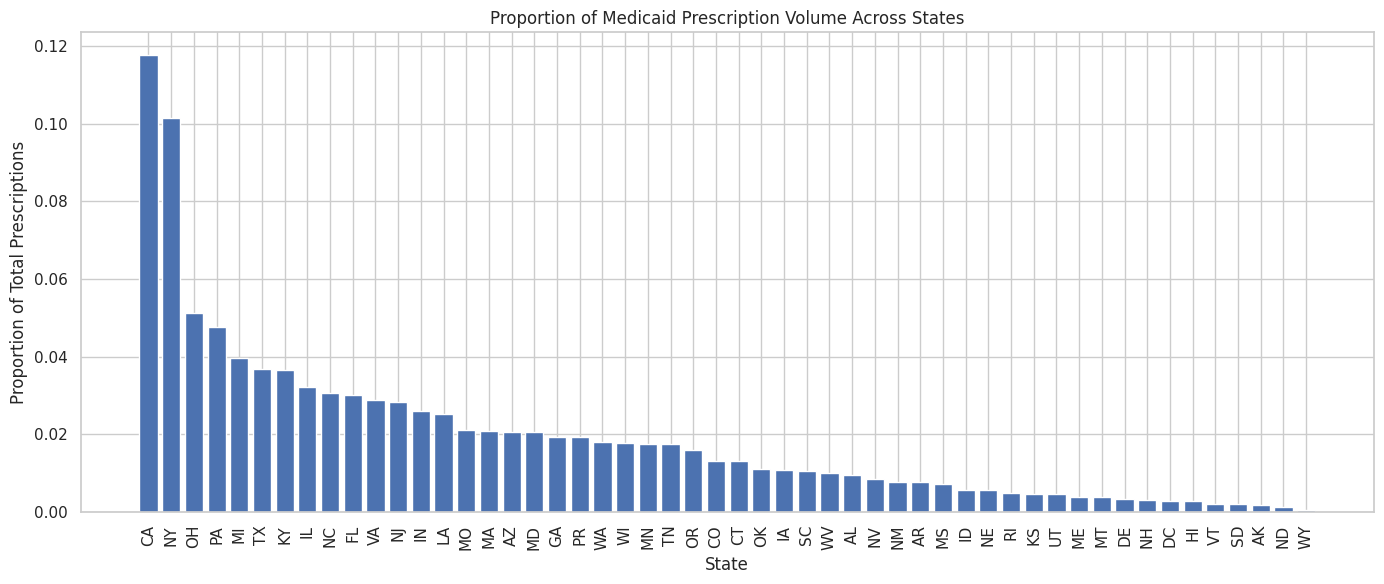

In [3]:
# Plot
plt.figure(figsize=(14, 6))
plt.bar(state_volume["State"], state_volume["Proportion"])

plt.title("Proportion of Medicaid Prescription Volume Across States")
plt.xlabel("State")
plt.ylabel("Proportion of Total Prescriptions")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()